In [1]:
# paso3_metricas_randomforest_opt.py
# Métricas de evaluación para el modelo RandomForest optimizado

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)
import matplotlib.pyplot as plt

In [6]:
# 1) Cargar dataset
datos = pd.read_csv("caracteristicas.csv")

In [7]:
# 2) Definir X (características) e y (etiqueta)
X = datos.drop(columns=["hipoxia", "marca_tiempo", "estacion"], errors="ignore")
y = datos["hipoxia"].astype(int)

In [11]:
# 3) División entrenamiento / prueba
X_ent, X_pru, y_ent, y_pru = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)

In [12]:
# 4) Definir cuadrícula de hiperparámetros (igual al paso 2)
parametros = {
    'criterion': ('gini', 'entropy', 'log_loss'),
    'max_features': ('sqrt', 'log2', None),
    'n_estimators': np.arange(10, 101, 10)
}

In [13]:
# 5) Optimización con GridSearchCV (10-fold CV)
modelo_base = RandomForestClassifier(random_state=42, n_jobs=-1)
busqueda = GridSearchCV(modelo_base, parametros, cv=10, n_jobs=-1)
busqueda.fit(X_ent, y_ent)

print("Mejores hiperparámetros encontrados:", busqueda.best_params_)
print("Exactitud media en validación (CV=10):", busqueda.best_score_)


Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_features': None, 'n_estimators': np.int64(80)}
Exactitud media en validación (CV=10): 0.9979257749018344


In [14]:
# 6) Modelo optimizado final
modelo_opt = RandomForestClassifier(
    criterion=busqueda.best_params_['criterion'],
    max_features=busqueda.best_params_['max_features'],
    n_estimators=int(busqueda.best_params_['n_estimators']),
    random_state=42,
    n_jobs=-1
)
modelo_opt.fit(X_ent, y_ent)


,n_estimators,80
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
# 7) Predicciones
y_pred = modelo_opt.predict(X_pru)
y_prob = modelo_opt.predict_proba(X_pru)[:, 1]


In [18]:
# 8) Métricas
acc  = accuracy_score(y_pru, y_pred)
prec = precision_score(y_pru, y_pred, zero_division=0)
rec  = recall_score(y_pru, y_pred, zero_division=0)
f1   = f1_score(y_pru, y_pred, zero_division=0)
auc  = roc_auc_score(y_pru, y_prob)
print("\n=== MÉTRICAS DEL MODELO OPTIMIZADO ===")
print(f"Exactitud (Accuracy): {acc:.3f}")
print(f"Precisión: {prec:.3f}")
print(f"Sensibilidad (Recall): {rec:.3f}")
print(f"F1-Score: {f1:.3f}")
print(f"ROC-AUC: {auc:.3f}")


=== MÉTRICAS DEL MODELO OPTIMIZADO ===
Exactitud (Accuracy): 0.998
Precisión: 0.988
Sensibilidad (Recall): 0.938
F1-Score: 0.963
ROC-AUC: 0.994


In [19]:
# 9) Matriz de confusión y reporte de clasificación
print("\nMatriz de confusión:")
print(confusion_matrix(y_pru, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_pru, y_pred, digits=3, zero_division=0))



Matriz de confusión:
[[28991    10]
 [   55   835]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.998     1.000     0.999     29001
           1      0.988     0.938     0.963       890

    accuracy                          0.998     29891
   macro avg      0.993     0.969     0.981     29891
weighted avg      0.998     0.998     0.998     29891



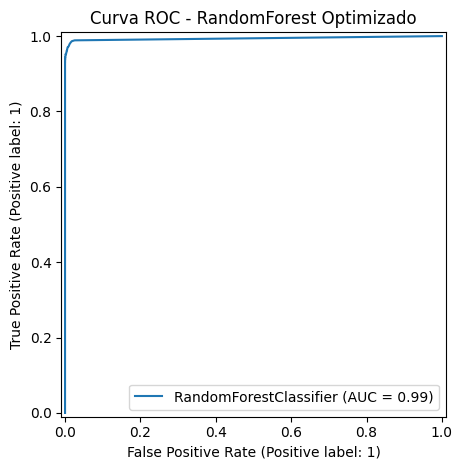

In [20]:
# 10) Curva ROC
RocCurveDisplay.from_estimator(modelo_opt, X_pru, y_pru)
plt.title("Curva ROC - RandomForest Optimizado")
plt.tight_layout()
plt.show()

In [ ]:
#Los mejores hiperparámetros elegidos por GridSearchCV.
#Exactitud en validación (CV=10).
#Exactitud, precisión, recall, F1 y ROC-AUC en el conjunto de prueba.
#Matriz de confusión y reporte por clase.
#Gráfica de la curva ROC.